# **Simple Linear Regression - Height/Weight**

In [4]:
# @title
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline

In [5]:
# @title
df = pd.read_csv("../datasets/height-weight.csv")
print(df)
print(df.shape)

    Weight  Height
0       45     120
1       58     135
2       48     123
3       60     145
4       70     160
5       78     162
6       80     163
7       90     175
8       95     182
9       78     170
10      82     176
11      95     182
12     105     175
13     100     183
14      85     170
15      78     177
16      50     140
17      65     159
18      76     150
19      87     167
20      45     129
21      56     140
22      72     160
(23, 2)


Text(0, 0.5, 'Height')

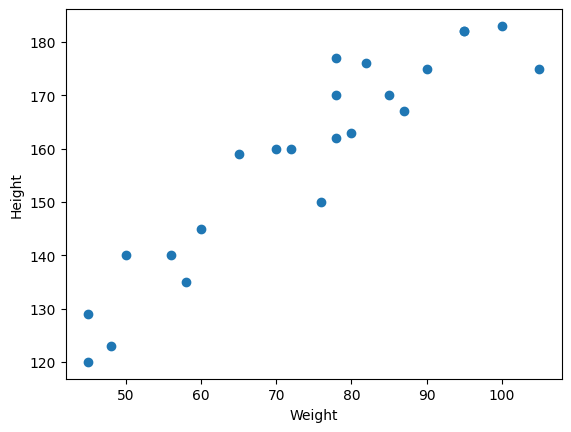

In [6]:
# @title
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [7]:
# @title
# correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [8]:
# @title
y = df['Weight'] # Independent feature should be in 2D array
x = df[['Height']] # Dependent feature can be in series - 1D array
x.head()

,Height
0,120
1,135
2,123
3,145
4,160


In [9]:
# Train test split
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)
print(f"X train: {x_train.shape}")
print(f"X test: {x_test.shape}")
print(f"Y train: {y_train.shape}")
print(f"Y test: {y_test.shape}")

X train: (17, 1)
X test: (6, 1)
Y train: (17,)
Y test: (6,)


In [10]:
# Strandardization - to make each data point in same unit. Use mean & standard daviation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train) # fit_transform for training only as it will calculate mean & standard daviation
x_test = scaler.transform(x_test) # transform for testing only as it will use calculated mean & ""

In [11]:
# Applying linear regression
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [12]:
regression.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
print(regression.coef_)
print(regression.intercept_)

[15.84018607]
72.47058823529412


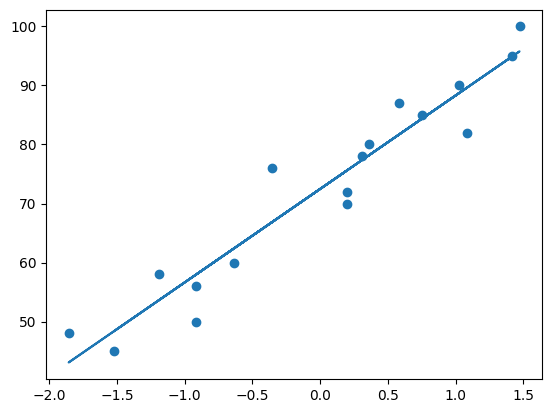

In [14]:
plt.scatter(x_train,y_train)
plt.plot(x_train,regression.predict(x_train))

In [15]:
y_pred = regression.predict(x_test)

In [16]:
# Performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse,mae,rmse)

95.97176782989375 8.247128517477355 9.796518148296045


In [17]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
score

0.7469247259100369

In [18]:
regression.predict(scaler.transform([[178]]))

d:\ML\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([91.3888321])

# **Multiple Linear Regression - Economic Index**

In [19]:
df_index = pd.read_csv("./drive/MyDrive/udemy-ml-nlp/economic_index.csv")
df_index.head()

FileNotFoundError: [Errno 2] No such file or directory: './drive/MyDrive/udemy-ml-nlp/economic_index.csv'

In [ ]:
# Dropping unneccessary columns
df_index.drop(columns=['Unnamed: 0','year','month'],axis=1,inplace=True) # inplace updates df itself

In [ ]:
df_index.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


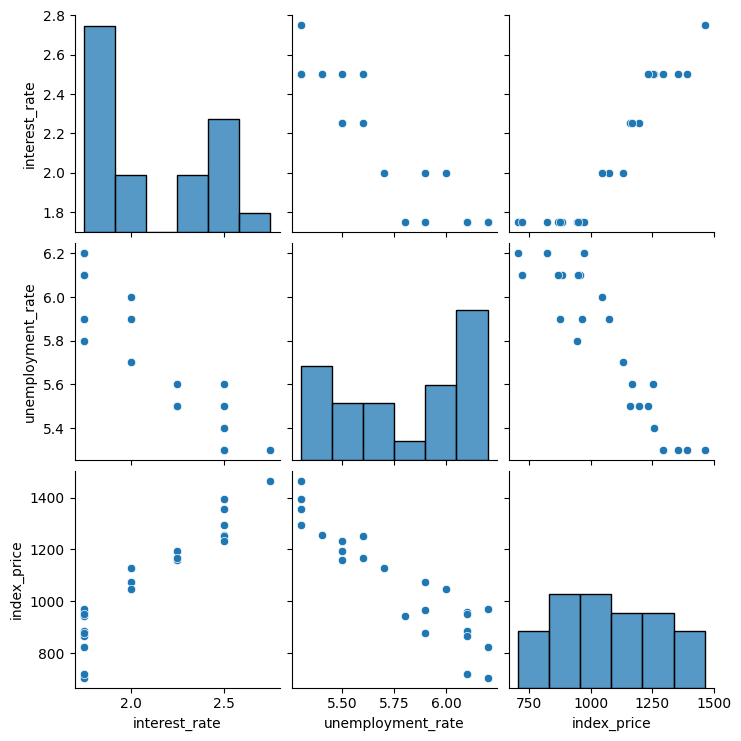

In [ ]:
import seaborn as sns
sns.pairplot(df_index)

In [ ]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment Rate')

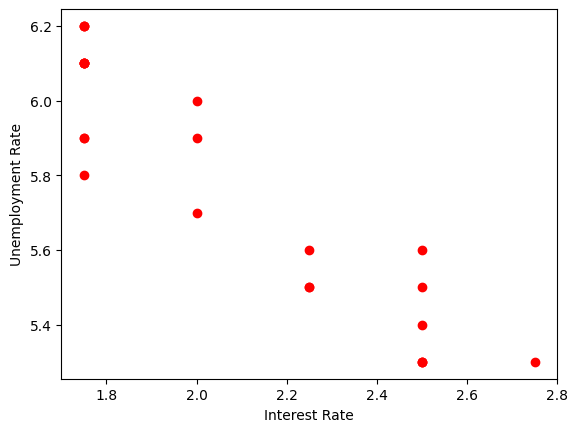

In [ ]:
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='r')
plt.xlabel("Interest Rate")
plt.ylabel("Unemployment Rate")

In [ ]:
x = df_index.iloc[:,:-1]
y = df_index.iloc[:,-1]
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


<Axes: xlabel='interest_rate', ylabel='index_price'>

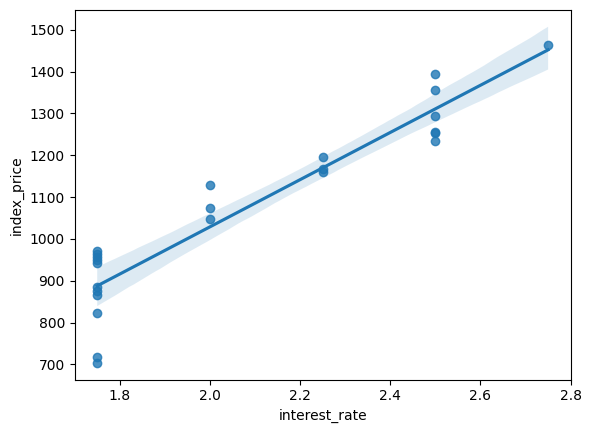

In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.25,random_state=42)
sns.regplot(x=df_index['interest_rate'],y=df_index['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

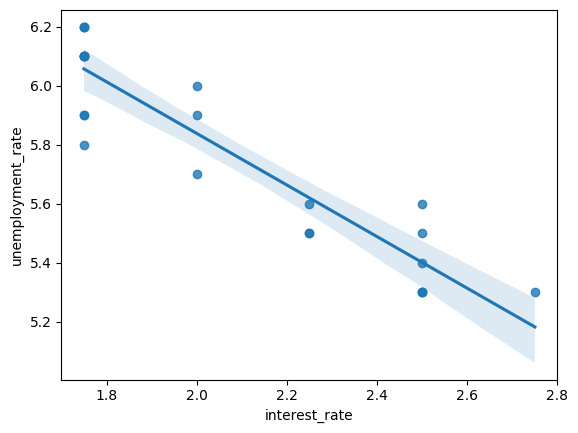

In [ ]:
sns.regplot(x=df_index['interest_rate'],y=df_index['unemployment_rate'])

In [ ]:
multi_scaler = StandardScaler()
xtrain = multi_scaler.fit_transform(xtrain)
xtest = multi_scaler.fit_transform(xtest)
xtrain

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [ ]:
multiple_regression = LinearRegression()
multiple_regression.fit(xtrain,ytrain)

LinearRegression()

In [ ]:
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(multiple_regression,xtrain,ytrain,scoring='neg_mean_squared_error',cv=3)
# cross validation with cv=3 means train data points will calculate points/cv=x. first x will be for test
# and others for train. Now next x for test and others for train and so on...

In [ ]:
np.mean(validation_score)

np.float64(-5914.828180162386)

In [ ]:
ypred = multiple_regression.predict(xtest)
ypred

array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

In [ ]:
# Performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse = mean_squared_error(ytest,ypred)
mae = mean_absolute_error(ytest,ypred)
rmse = np.sqrt(mse)
print(mse,mae,rmse)

8108.567426306604 73.80444932337097 90.04758423359621


In [ ]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
score

0.7469247259100369

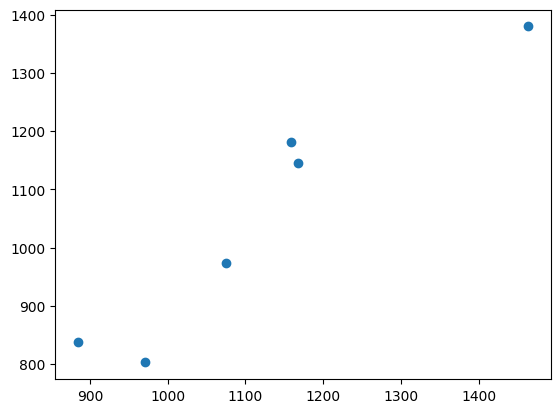

In [ ]:
plt.scatter(ytest,ypred)

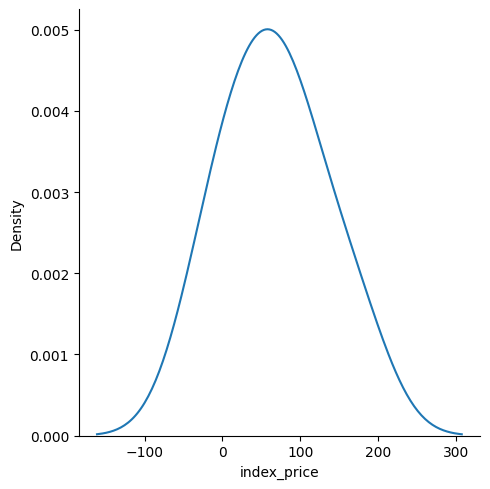

In [ ]:
errors = ytest-ypred
sns.displot(errors,kind='kde')

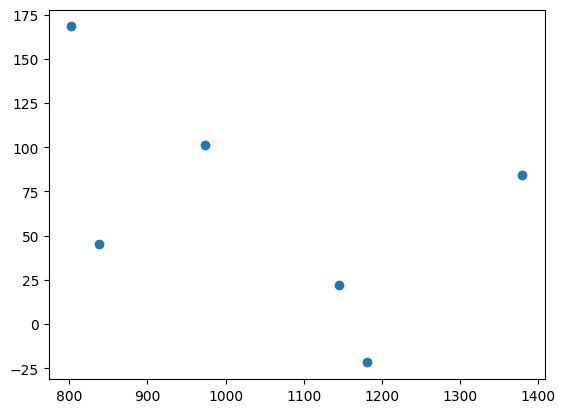

In [ ]:
plt.scatter(ypred,errors)

# **Polynomial Regression**

In [ ]:
# creating dummy dataset
x = 6 * np.random.rand(100,1) - 3
y = 0.5 * x**2 + 1.5*x + 2 + np.random.randn(100,1)

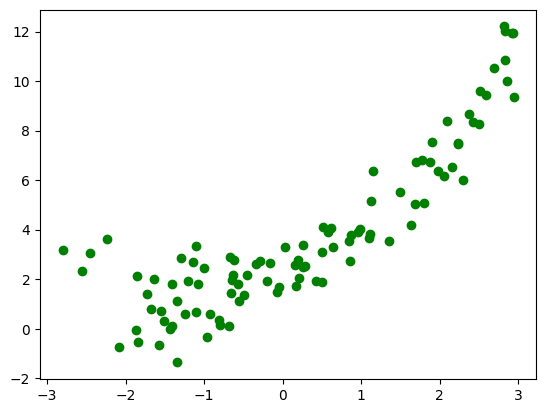

In [ ]:
plt.scatter(x,y,c="g")

In [ ]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
linear = LinearRegression()
linear.fit(xtrain,ytrain)

LinearRegression()

In [ ]:
score = r2_score(ytest,linear.predict(xtest))
score

0.5036329063458469

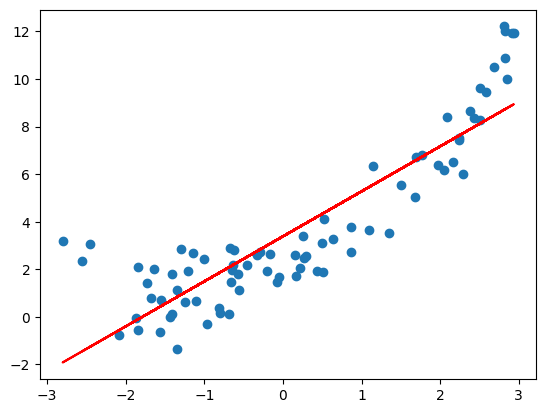

In [ ]:
plt.plot(xtrain,linear.predict(xtrain),c='r')
plt.scatter(xtrain,ytrain)

In [ ]:
# applying polynomial transformation
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2,include_bias=True)
xtrain_poly = poly.fit_transform(xtrain)
xtest_poly = poly.transform(xtest)

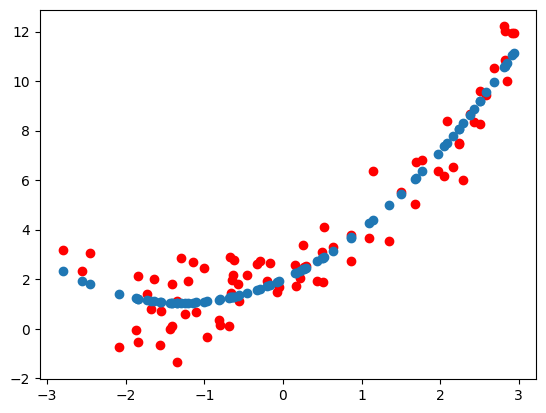

In [ ]:
polyomial_model = LinearRegression()
polyomial_model.fit(xtrain_poly,ytrain)
score = r2_score(ytest,polyomial_model.predict(xtest_poly))
score
plt.scatter(xtrain,ytrain,c='r')
plt.scatter(xtrain,polyomial_model.predict(xtrain_poly))